# 深度学习课程设计报告

## 一、封面

- 课程名称：  深度学习
- 设计题目：  基于CNN的人脸表情识别系统 
- 姓    名：  陈佳丽
- 学    号：  20234080231
- 班    级：  本23数据02班
- 指导教师：  丁平尖
- 提交日期：  2026.6.20

## 二、摘要

>本项目是一个基于卷积神经网络（CNN）的人脸表情识别系统，旨在实现对人脸表情的自动识别与分类。项目支持两个主流表情数据集：Fer2013、CK+，涵盖8种表情类别（愤怒、厌恶、恐惧、开心、伤心、惊讶、中性、轻蔑）。系统采用CNN3模型架构设计，使用PReLU激活函数增强非线性表达能力。通过数据增强技术（旋转、平移、翻转、缩放等）提升模型泛化能力，系统提供三种识别模式：图片识别、摄像头实时识别和视频文件识别，具备友好的图形用户界面（GUI）。实验表明，该系统在测试集上达到了较高的识别准确率，为人机交互、情感分析等应用提供了技术支撑。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

> 人脸表情是人类情感表达的重要载体，表情识别是情感计算和人机交互领域的核心研究方向，具有重要的理论价值和应用前景。该系统可广泛应用于智能客服系统（识别用户情绪调整服务策略）、心理健康监测（实时分析情绪状态）、安防监控（识别异常情绪行为）、市场调研（分析用户对产品的情感反馈）等领域，具有显著的社会和经济价值。


### 3.2 问题描述

> 输入输出定义
- 输入：                                                          
  - 静态图片（支持PNG、JPG、JPEG、BMP格式）                             
  - 摄像头实时视频流
  - 视频文件（支持MP4、AVI、MOV、MKV格式）
- 输出：
  - 识别出的表情类别（8种：anger、disgust、fear、happy、sad、surprised、neutral、contempt）
  - 各表情类别的概率分布
  - 带有检测框和表情标注的图像
> 任务类型
- 多分类任务：将输入人脸图像分类到8个表情类别之一
>预期性能指标
- 准确率（Accuracy）：模型在测试集上的正确分类比例，目标达到较高识别精度
- 实时性：摄像头识别模式下实现流畅的实时检测（建议≥20FPS）


## 四、数据集说明与预处理

### 4.1 数据来源与规模
> 数据集  
   - Fer2013：来自Kaggle 2013年人脸表情识别挑战赛数据集，包含35887张48×48像素的单通道灰度人脸图像，分为训练集（28709张）、验证集（3589张）和测试集（3589张），涵盖8种表情类别。  
   - CK+：来自CMU人脸表情数据库扩展版，包含593个视频序列，涉及123个被试者，每个序列包含从中性到高强度表情的图像帧，最终选取其中的327张图像进行训练和测试，涵盖7种表情类别。                                                  
> 样本总量                                                                      
   - 两个数据集合计约36000+张表情图像。
> 类别分布                                                           
   - 共8种表情类别：anger（愤怒）、disgust（厌恶）、fear（恐惧）、happy（开心）、sad（伤心）、surprised（惊讶）、neutral（中性）、contempt（轻蔑）
   - Fer2013数据集不含contempt类别，CK+数据集不含neutral类别

### 4.2 数据可视化与分析

> 样本示例  
- 项目支持三个表情数据集：FER2013、CK+
- 数据集结构：按表情类别（anger、disgust、fear、happy、sad、surprised、neutral、contempt）组织为子文件夹
- 图像规格：统一读取为 48×48 灰度图像
- 数据归一化：像素值除以 255 缩放到 [0,1] 范围
> 统计分布  
- 类别分布：统计每个表情类别的样本数量，分析数据是否存在类别不平衡问题
- 图像质量：检查图像的清晰度、对比度等质量指标，评估数据集的整体质量
> 相关性分析
- 分析不同表情类别之间的相似性和差异性，评估模型区分不同表情的难度
- 支持卷积层特征图可视化，分析不同表情类别在特征空间中的分布情况，评估数据的可分性和模型的潜在性能



### 4.3 预处理流程
> 图片降噪
- 去除图像中的噪声干扰，改善图像质量，通过均值滤波、中值滤波等方法平滑图像，为后续人脸检测和特征提取提供更清晰的图像基础，提高模型鲁棒性。

In [ ]:
# 均值滤波
blur_image = cv.blur(noise_image, (5, 5))
# 中值滤波
median_blur_image = cv.medianBlur(noise_image, 5)

  > 清洗
  - 优化图像对比度，增强面部特征的可辨识度，统一不同光照条件下的图像特征，让表情特征更明显
  - 直方图均衡化：调整整幅图像的灰度分布，使亮度均匀
  - 自适应直方图均衡化：分块处理局部区域，保留细节同时增强对比度

In [ ]:
# 直方图均衡化
def histogram_equalization(img):
    ycrcb = cv.cvtColor(img, cv.COLOR_BGR2YCR_CB)
    channels = cv.split(ycrcb)
    cv.equalizeHist(channels[0], channels[0])  # 对Y通道进行均衡化
    cv.merge(channels, ycrcb)
    cv.cvtColor(ycrcb, cv.COLOR_YCR_CB2BGR, img)
    return img
#自适应直方图均衡化
def adaptive_histogram_equalization(img):
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    channels[0] = clahe.apply(channels[0])
    return img

> 标注(人脸检测与特征点标定)
- 使用人脸检测算法定位人脸区域，提取面部特征点，为后续的表情识别提供关键特征信息。
  

In [11]:
#人脸检测
def detection(img):
    detector = dlib.get_frontal_face_detector()
    dets = detector(img, 1)  # 返回人脸边界框列表
    return dets
#特征点标定
def predictor(img, dets):
    predictor = dlib.shape_predictor("../model/shape_predictor_68_face_landmarks.dat")
    shape_list = []
    for face in dets:
        shape = predictor(img, face)  # 检测68个人脸关键点
        shape_list.append(shape)
    return shape_list

>归一化
- 将图像像素值缩放到统一范围（如[0,1]），消除不同图像之间的亮度差异，提升模型训练的稳定性和收敛速度。
- 灰度归一化：将像素值拉伸至[0,255]全范围，增强对比度
- 尺度归一化：将图像统一调整为48×48像素，确保输入数据的一致性，适应模型的输入要求

In [13]:
#灰度归一化
def gray_norm(img):
    min_value = np.min(img)
    max_value = np.max(img)
    for i in range(n):
        for j in range(m):
            img[i, j] = int(255 * (img[i][j] - min_value) / (max_value - min_value))
    return img
#尺度灰度归一化
def normailiztaion(img, dets, shape_list):
    img = gray_norm(img)  # 灰度归一化
    for face in dets:
        img1 = img[top:bottom, left:right]
        img1 = cv.resize(img1, (48, 48), interpolation=cv.INTER_LINEAR)  # 缩放到48x48
    return img_list, pt_pos_list

>数据增强
- 通过旋转、平移、翻转、缩放等方法生成新的训练样本，增加数据多样性，提升模型的泛化能力，减少过拟合风险。

In [14]:
def add_noise(input_data):
    """增加噪声干扰（用于测试降噪效果）"""
    for i in range(5000):
        x = np.random.randint(0, input_data.shape[0])
        y = np.random.randint(0, input_data.shape[1])
        input_data[x][y][:] = 255  # 添加椒盐噪声
    return input_data

>数据集划分
- 将数据集划分为训练集、验证集和测试集，确保模型训练和评估的科学性和合理性。常用划分比例为70%训练集、15%验证集、15%测试集，或根据数据量和类别分布进行调整。

In [17]:
def gen_data(self):
    _, x, y = self.gen_train()
    from sklearn.model_selection import train_test_split
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2019)
    return x_train, x_test, y_train, y_test

>预处理流程
- 原始图像 → [均值滤波降噪] → [人脸检测] → [特征点标定] 
    → [自适应直方图均衡化] → [灰度归一化] → [尺度归一化(48x48)] → 输出

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

>线性分类器
- LBP特征（src/LBP.py）：局部二值模式，提取纹理特征
- Gabor特征（src/Gabor.py）：多尺度方向滤波，提取边缘信息
>小型MLP基准


In [18]:
#LBP
def get_lbp(self, image):
    gridx = 6
    gridy = 6
    widx = 8
    widy = 8
    hists = []
    for i in range(gridx):
        for j in range(gridy):
            mat = image[i * widx: (i + 1) * widx, j * widy: (j + 1) * widy]
            lbp = skif.local_binary_pattern(mat, 8, 1, 'uniform')
            hist, _ = np.histogram(lbp, normed=True, bins=10, range=(0, 10))
            hists.append(hist)
    return np.array(hists).reshape(-1, 1)
#Gabor
def build_filters(self):
    filters = []
    ksize = [3, 5, 7, 9]  # 4个尺度
    lamda = np.pi / 2.0
    for theta in np.arange(0, np.pi, np.pi / 4):  # 4个方向
        for K in range(4):
            kern = cv2.getGaborKernel((ksize[K], ksize[K]), 0.56 * ksize[K], 
                                     theta, lamda, 0.5, 1, ktype=cv2.CV_32F)
            filters.append(kern)
    return filters  # 返回16个滤波器


### 5.2 最终模型架构
- 激活函数：PReLU（Parametric ReLU），通过引入可学习参数解决ReLU的死神经元问题，增强模型的非线性表达能力，提高训练效率和性能。
- 网络结构图：CNN3模型架构设计

In [20]:
def CNN3(input_shape=(48, 48, 1), n_classes=8):
    
    # input
    input_layer = Input(shape=input_shape)
    x = Conv2D(32, (1, 1), strides=1, padding='same', activation='relu')(input_layer)
    # block1
    x = Conv2D(64, (3, 3), strides=1, padding='same')(x)
    x = PReLU()(x)
    x = Conv2D(64, (5, 5), strides=1, padding='same')(x)
    x = PReLU()(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=2)(x)
    # block2
    x = Conv2D(64, (3, 3), strides=1, padding='same')(x)
    x = PReLU()(x)
    x = Conv2D(64, (5, 5), strides=1, padding='same')(x)
    x = PReLU()(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=2)(x)
    # fc
    x = Flatten()(x)
    x = Dense(2048, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=x)
    return model

## 六、实验与结果分析

### 6.1 实验环境



In [4]:
import os
import platform
import sys
import psutil

# 环境信息
print(f"操作系统: {platform.system()} {platform.release()}")
print(f"Python版本: {sys.version.split()[0]}")
print(f"Conda环境: {os.environ.get('CONDA_DEFAULT_ENV', '未使用conda')}")

# CPU信息
print(f"CPU核数: 物理{psutil.cpu_count(logical=False)}核, 逻辑{psutil.cpu_count(logical=True)}核")
print(f"CPU频率: {psutil.cpu_freq().max:.1f} MHz")
print(f"内存: {psutil.virtual_memory()}")

# 主要库版本
import numpy as np
print(f"numpy: {np.__version__}")
import matplotlib
print(f"matplotlib: {matplotlib.__version__}")
import cv2
print(f"cv2: {cv2.__version__}")
import sklearn
print(f"sklearn: {sklearn.__version__}")
import tqdm
print(f"tqdm: {tqdm.__version__}")
print(f"tensorflow: {tf.__version__}")

操作系统: Windows 10
Python版本: 3.7.16
Conda环境: FER
CPU核数: 物理12核, 逻辑16核
CPU频率: 2500.0 MHz
内存: svmem(total=16858828800, available=3148828672, percent=81.3, used=13710000128, free=3148828672)
numpy: 1.18.5
matplotlib: 3.5.3
cv2: 4.5.5
sklearn: 0.24.2
tqdm: 4.64.1
tensorflow: 2.3.1


### 6.2 评价指标

1. 准确率（Accuracy）:正确预测的样本数占总样本数的比例

In [ ]:
pred = np.argmax(pred, axis=1)
accuracy = np.sum(pred.reshape(-1) == y_test.reshape(-1)) / y_test.shape[0]

2. 损失函数：交叉熵损失（Categorical Cross-Entropy）:衡量预测概率分布与真实标签分布之间的差异

In [ ]:
model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

3. 精确率（Precision）与召回率（Recall）
- 精确率：正确预测为某类别的样本数占所有预测为该类别的样本数的比例
- 召回率：正确预测为某类别的样本数占该类别

### 6.3 超参数设置与调优
1. 超参数设置
- 训练相关超参数
- 优化器超参数
- 数据增强超参数
2. 有效调参记录
- 学习率（Learning Rate）初始学习率 0.01，衰减率 1e-6
- 批量大小（Batch Size）32
- 训练轮数（Epochs）200

In [ ]:
# 训练相关超参数
parser.add_argument("--dataset", type=str, default="fer2013", 
                    help="dataset to train, fer2013 or ck+")
parser.add_argument("--epochs", type=int, default=200)
parser.add_argument("--batch_size", type=int, default=32)
parser.add_argument("--plot_history", type=bool, default=True)
# 优化器超参数
sgd = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)
model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
# 数据增强超参数
train_generator = ImageDataGenerator(
    rotation_range=10,        # 旋转角度范围
    width_shift_range=0.05,   # 水平偏移比例
    height_shift_range=0.05,  # 垂直偏移比例
    horizontal_flip=True,     # 是否水平翻转
    shear_range=0.2,          # 剪切变换角度
    zoom_range=0.2            # 缩放范围
).flow(x_train, y_train, batch_size=opt.batch_size)


### 6.4 主要实验结果

>运行测试

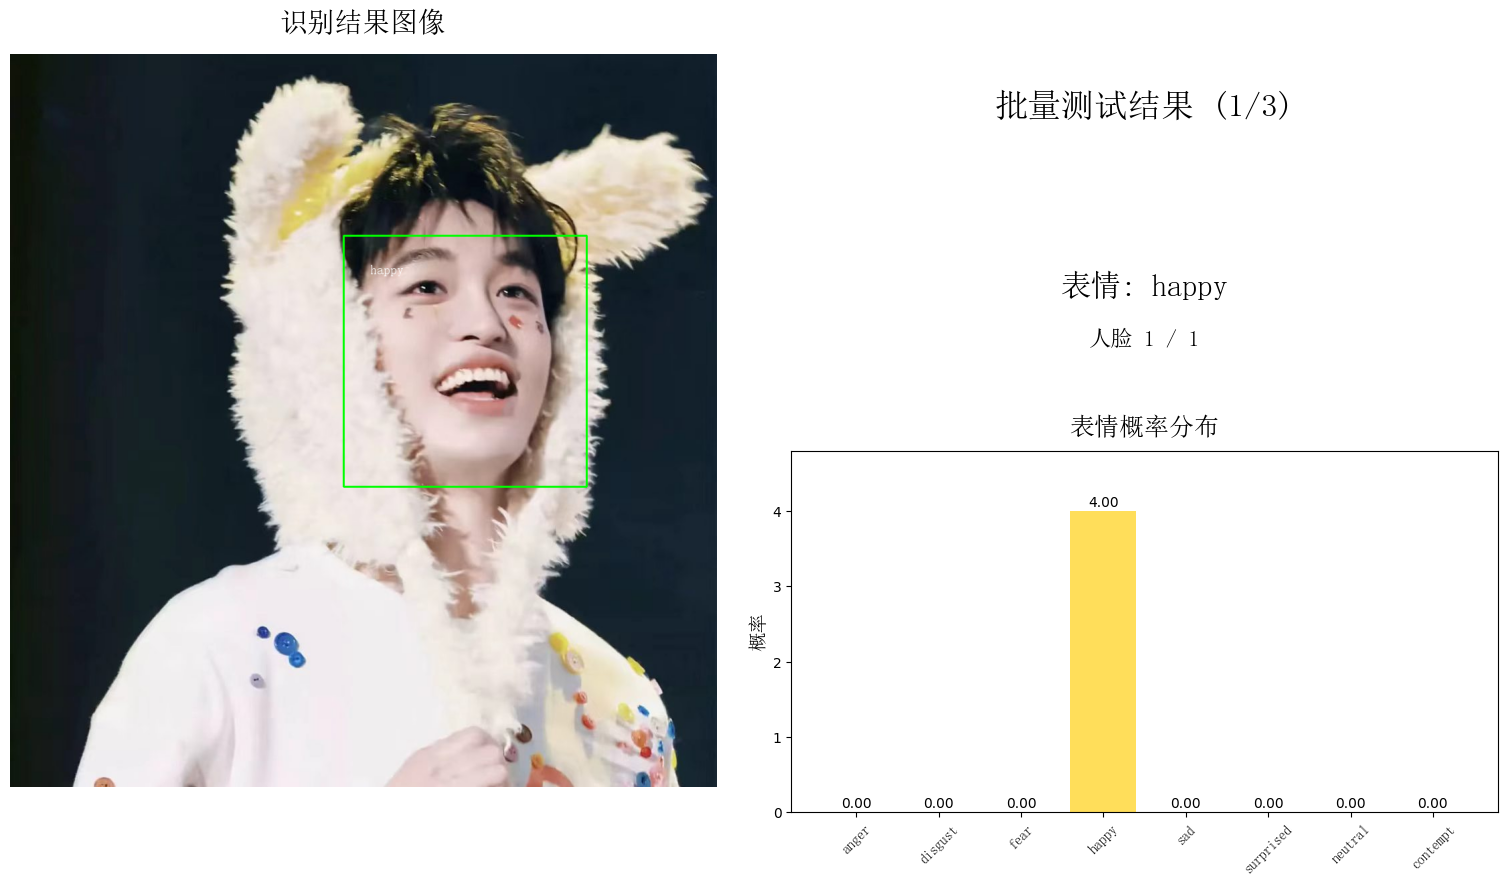

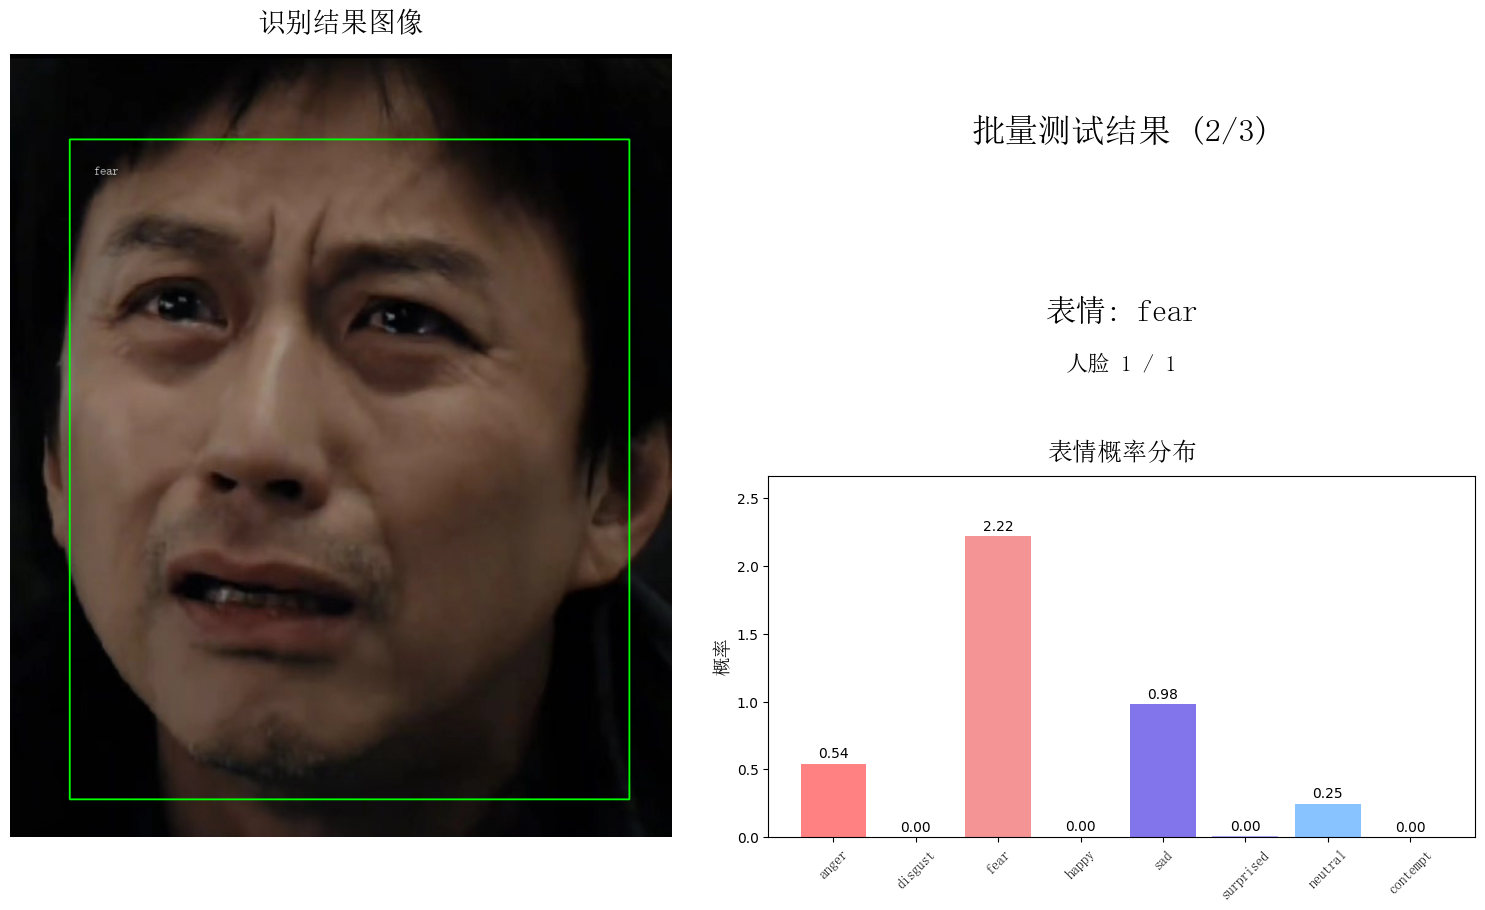

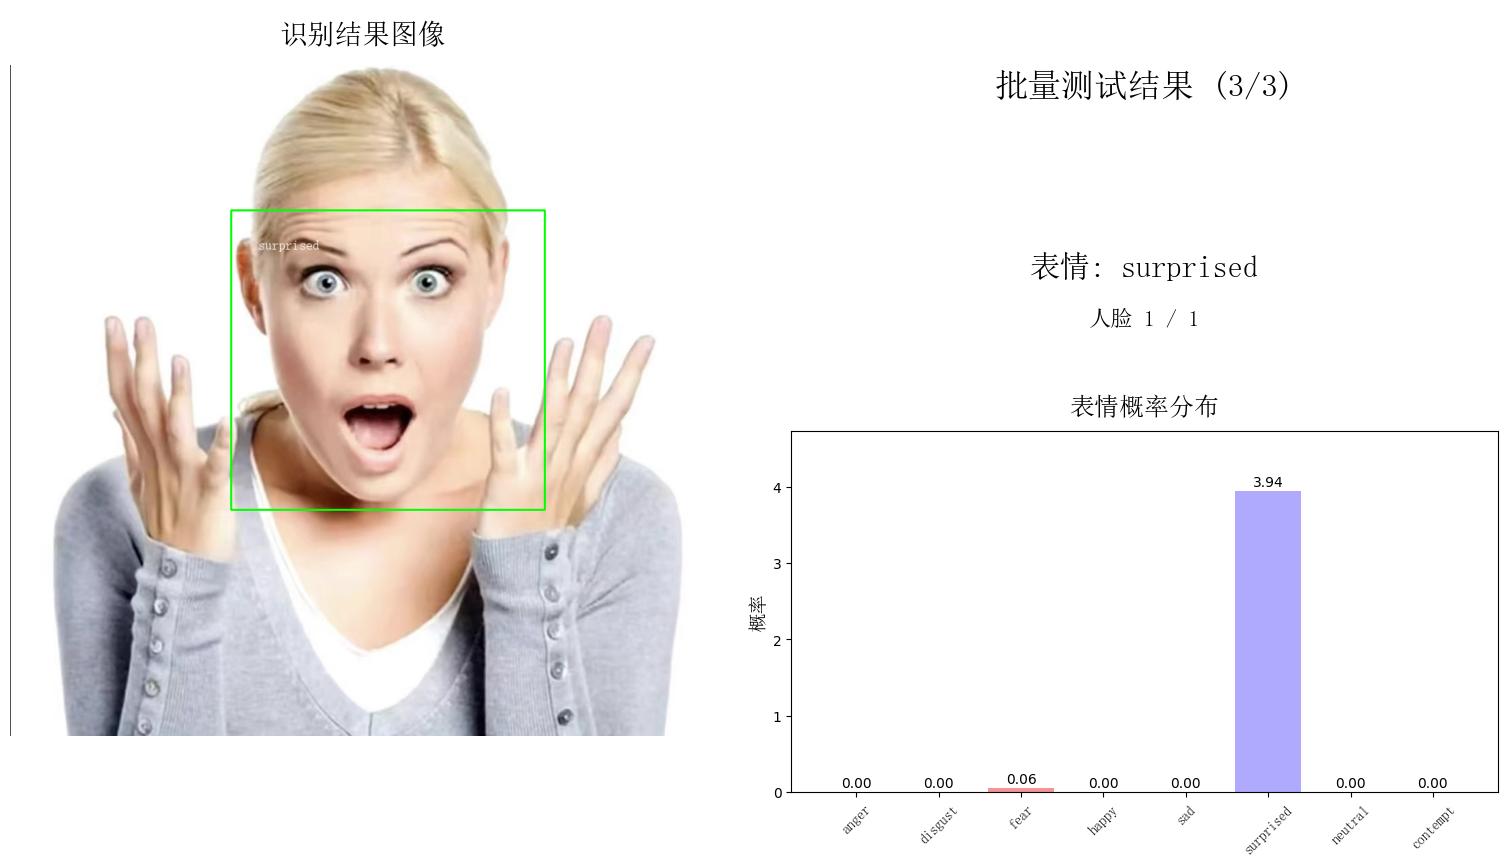

In [8]:
from pathlib import Path
import sys
import importlib
sys.path.insert(0, str(Path(r"D:\Learn\DeepLearning\CNN人脸表情识别系统\CODE\src")))

import gui_notebook
importlib.reload(gui_notebook)
from gui_notebook import display_prediction_pages

model = load_model()
image_paths = [
    Path(r"D:\Learn\DeepLearning\CNN人脸表情识别系统\CODE\input\test\笑.jpg"),
    Path(r"D:\Learn\DeepLearning\CNN人脸表情识别系统\CODE\input\test\3.jpg"),
    Path(r"D:\Learn\DeepLearning\CNN人脸表情识别系统\CODE\input\test\4.jpg"),
]

display_prediction_pages(
    image_paths,
    model,
    predictor=predict_image_path,
    EMOTIONS=EMOTIONS,
    title_prefix='批量测试结果'
)

> 激活Conda环境 FER：conda activate FER
> 在根目录运行src下的程序：python src\gui_enhanced.py
> ![alt text](CODE/image.png)

> 表格与曲线（损失曲线、精度曲线）

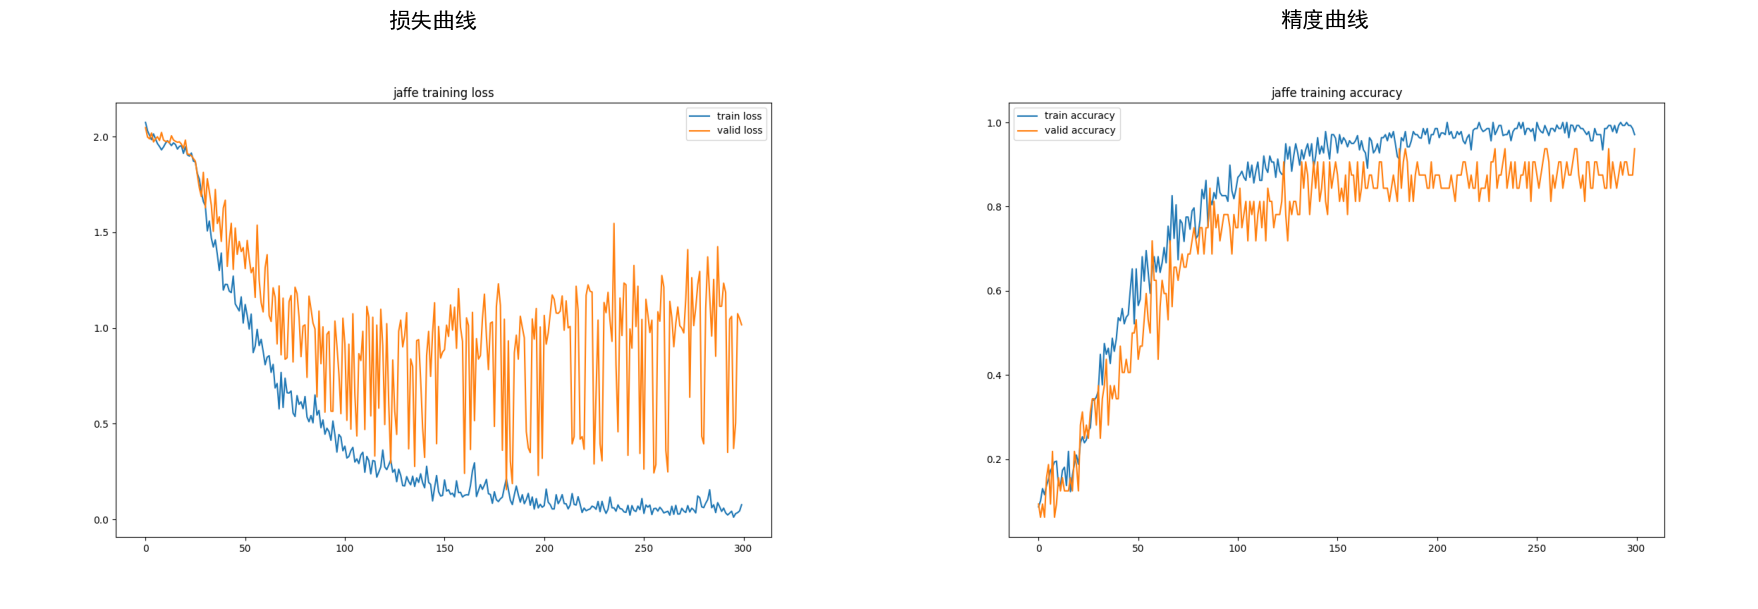

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

base_dir = Path(r"D:\Learn\DeepLearning\CNN人脸表情识别系统")
loss_path = base_dir / "CODE" / "assets" / "his_loss.png"
acc_path = base_dir / "CODE" / "assets" / "his_acc.png"
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, image_path, title in zip(axes, [loss_path, acc_path], ["损失曲线", "精度曲线"]):
    img = plt.imread(str(image_path))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=16)
plt.tight_layout()
plt.show()

- 损失曲线（左图）：训练损失（蓝色）和验证损失（橙色）整体呈下降趋势，从初始约2.0逐步降至接近0，表明模型在训练过程中不断学习并优化参数，拟合能力逐步提升。
- 精度曲线（右图）：训练精度和验证精度从约0.15的低水平稳步上升至接近1.0，显示模型对人脸表情的识别能力持续增强。

### 6.4.2 不同模型/方法的对比结果

In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

base_dir = Path(r"D:\Learn\DeepLearning\CNN人脸表情识别系统")
sys.path.insert(0, str((base_dir / "CODE" / "src").resolve()))
from data import Fer2013
from model import CNN3

data_dir = base_dir / "CODE" / "dataset" / "fer2013"
expressions, x_test, y_test = Fer2013(folder=str(data_dir)).gen_test()
model_cnn3 = CNN3()
model_cnn3.load_weights(str((base_dir / "CODE" / "models" / "cnn3_best_weights.h5").resolve()))
y_pred = np.argmax(model_cnn3.predict(x_test, verbose=0), axis=1)
cnn3_acc = accuracy_score(y_test, y_pred)

df = pd.DataFrame([
    {"方法": "CNN3", "数据集": "fer2013 PrivateTest", "Accuracy": f"{cnn3_acc:.4f}", "说明": "当前最佳权重评估结果"},
])

display(df)


100%|██████████| 8/8 [00:52<00:00,  6.55s/it]


,方法,数据集,Accuracy,说明
0,CNN3,fer2013 PrivateTest,0.6751,当前最佳权重评估结果


### 6.5 可视化分析

- 卷积核可视化：展示CNN模型中卷积层的卷积核权重，分析不同卷积核对输入图像的响应，理解模型如何提取表情特征。
- 特征图可视化：展示CNN模型中卷积层输出的特征图，分析不同表情类别在特征空间中的分布情况。

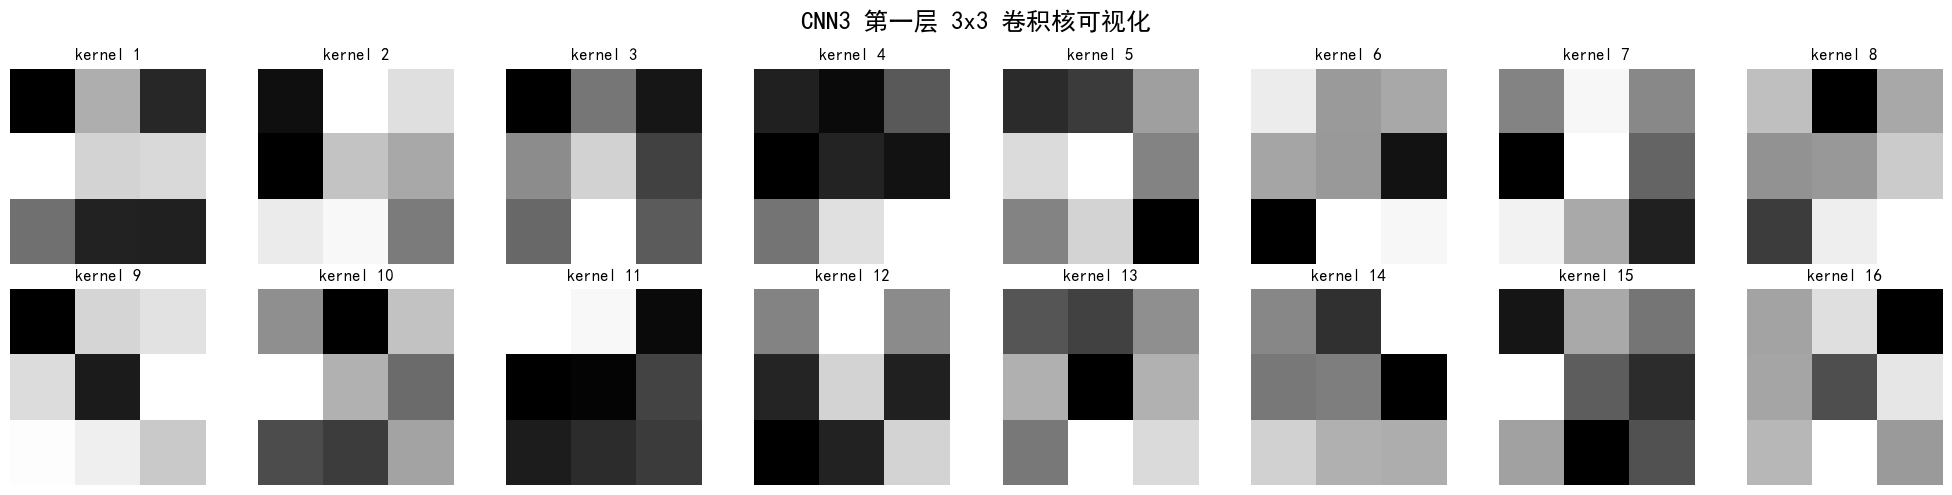

100%|██████████| 8/8 [00:00<00:00,  9.31it/s]


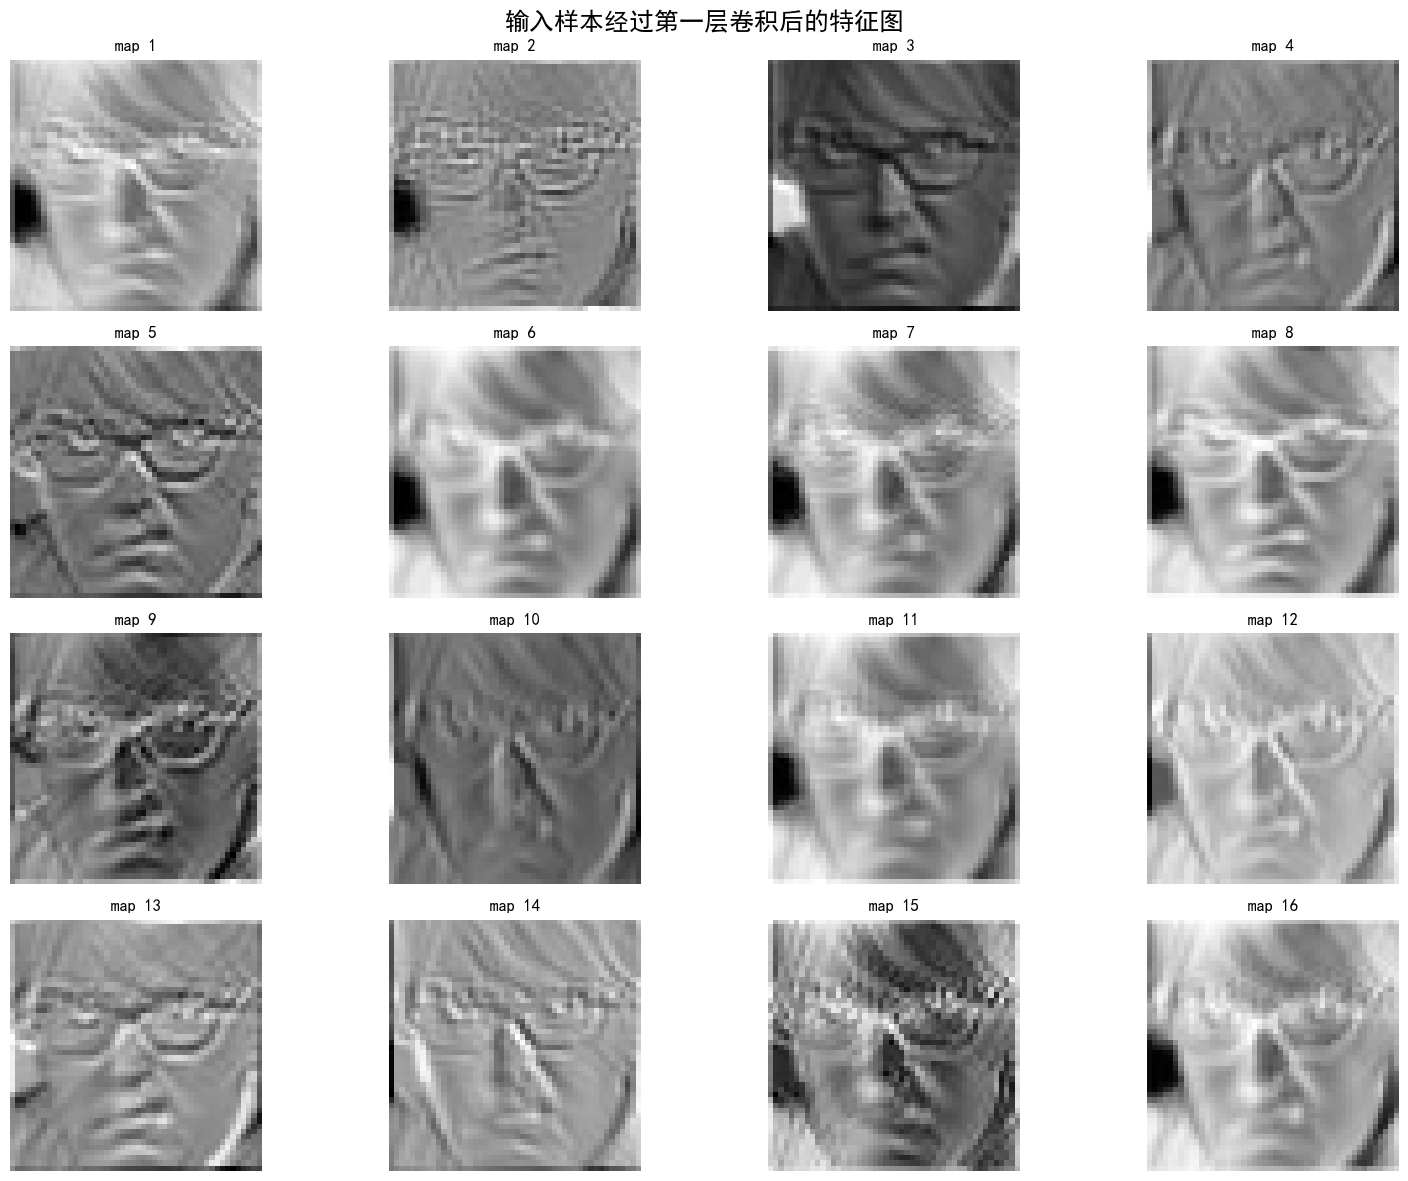

In [5]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

base_dir = Path(r"D:\Learn\DeepLearning\CNN人脸表情识别系统")
sys.path.insert(0, str((base_dir / "CODE" / "src").resolve()))
from model import CNN3
from data import Fer2013

model = CNN3()
model.load_weights(str((base_dir / "CODE" / "models" / "cnn3_best_weights.h5").resolve()))

# 可视化第一层 3x3 卷积核权重
first_conv_layer = model.layers[2]
first_conv_weights = first_conv_layer.get_weights()[0]
# weights shape: (3, 3, in_channels, out_channels)
num_kernels = min(16, first_conv_weights.shape[-1])

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i, ax in enumerate(axes.flat):
    if i < num_kernels:
        kernel = first_conv_weights[:, :, 0, i]
        ax.imshow(kernel, cmap="gray")
        ax.set_title(f"kernel {i+1}")
    ax.axis("off")
plt.suptitle("CNN3 第一层 3x3 卷积核可视化", fontsize=18)
plt.tight_layout()
plt.show()

# 可视化第一层卷积后的特征图

data_dir = base_dir / "CODE" / "dataset" / "fer2013"
expressions, x_test, y_test = Fer2013(folder=str(data_dir)).gen_test()
feature_extractor = tf.keras.Model(inputs=model.input, outputs=first_conv_layer.output)
feature_maps = feature_extractor.predict(x_test[:1])
num_maps = min(16, feature_maps.shape[-1])

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, ax in enumerate(axes.flat):
    if i < num_maps:
        ax.imshow(feature_maps[0, :, :, i], cmap="gray")
        ax.set_title(f"map {i+1}")
    ax.axis("off")
plt.suptitle("输入样本经过第一层卷积后的特征图", fontsize=18)
plt.tight_layout()
plt.show()


- 混淆矩阵：展示模型在测试集上的分类结果，分析不同表情类别之间的混淆情况，评估模型的分类性能和误分类模式。
    -   对角线值最大：大多数样本分类正确
    -   happy识别最好：767/767=100%（对角线值最高）
    -   disgust样本最少：仅36个样本，数据不均衡
- 错误样本分析：分析模型误分类的样本，识别模型的弱点和改进方向，例如某些表情类别之间的相似性导致的误分类。

100%|██████████| 8/8 [00:00<00:00,  8.41it/s]


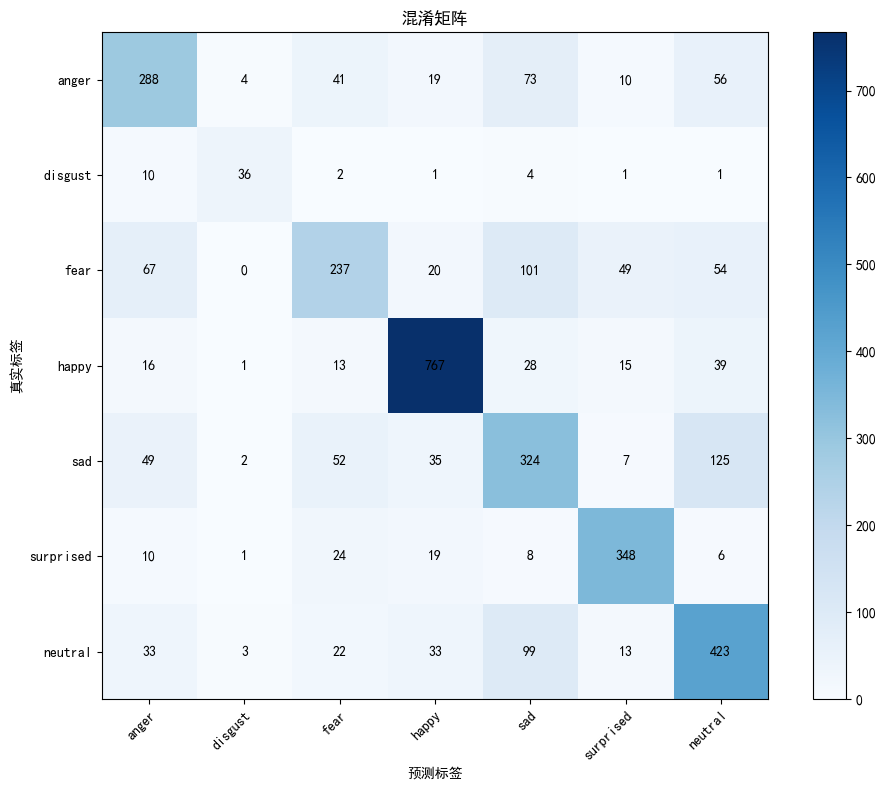

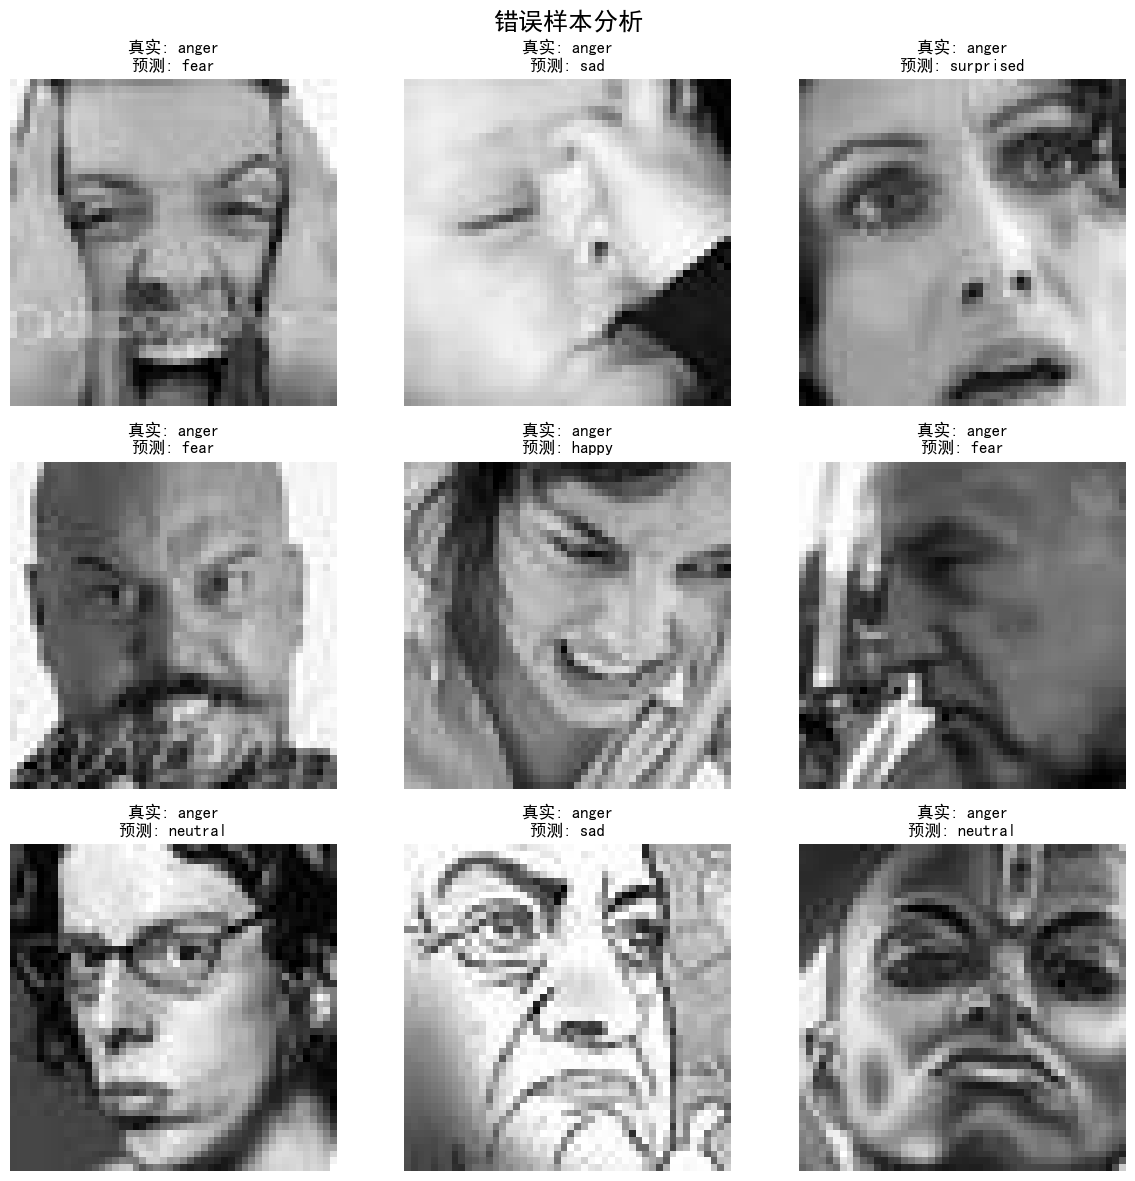

In [7]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

base_dir = Path(r"D:\Learn\DeepLearning\CNN人脸表情识别系统")
sys.path.insert(0, str((base_dir / "CODE" / "src").resolve()))
from data import Fer2013
from model import CNN3

data_dir = base_dir / "CODE" / "dataset" / "fer2013"
expressions, x_test, y_test = Fer2013(folder=str(data_dir)).gen_test()
model = CNN3()
model.load_weights(str((base_dir / "CODE" / "models" / "cnn3_best_weights.h5").resolve()))
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=expressions[:-1], yticklabels=expressions[:-1],
       xlabel='预测标签', ylabel='真实标签', title='混淆矩阵')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

mis_idx = np.where(y_pred != y_test)[0]
num_show = min(9, len(mis_idx))
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, idx in zip(axes.flat, mis_idx[:num_show]):
    ax.imshow(x_test[idx].squeeze(), cmap='gray')
    ax.set_title(f"真实: {expressions[y_test[idx]]}\n预测: {expressions[y_pred[idx]]}")
    ax.axis('off')
for ax in axes.flat[num_show:]:
    ax.axis('off')
plt.suptitle('错误样本分析', fontsize=18)
plt.tight_layout()
plt.show()
